# LangGraph 멀티에이전트 Supervisor

## 개요

멀티에이전트(Multi-agent) 시스템은 복잡한 애플리케이션을 여러 전문화된 에이전트로 나누어 함께 문제를 해결하는 아키텍처입니다. 단일 에이전트가 모든 작업을 처리하는 대신, 더 작고 집중된 에이전트들을 조정된 워크플로우로 구성하여 각 에이전트가 자신의 전문 분야에 집중할 수 있게 합니다.

멀티에이전트 아키텍처는 다음과 같은 상황에서 특히 유용합니다.

- **도구 과부하**: 단일 에이전트가 너무 많은 도구를 가지고 있어 어떤 것을 사용할지 잘못 결정하는 경우
- **컨텍스트 오버플로우**: 컨텍스트 또는 메모리가 한 에이전트가 효과적으로 추적하기에 너무 큰 경우
- **전문화 필요**: 작업에 전문화가 필요한 경우 (예: 계획자, 연구자, 수학 전문가)

> **참고 문서**: [LangChain Multi-Agent](https://docs.langchain.com/oss/python/langchain/multi-agent/)

### 실무 비유로 이해하기

일반적인 회사에서 **프로젝트 매니저** 가 팀을 관리하는 방식과 매우 유사합니다. 프로젝트 매니저(Supervisor)는 고객 요청을 분석하고 적절한 팀원에게 업무를 배정합니다. 개발팀(Research Agent)은 기술 조사와 정보 수집을 담당하고, 재무팀(Math Agent)은 예산 계산과 수치 분석을 담당합니다.

각 팀원은 자신의 전문 분야에만 집중하고, 매니저가 전체 프로젝트를 조율하는 구조입니다.

### Supervisor Pattern이란?

**Supervisor Pattern** 은 복잡한 작업을 여러 전문 에이전트에게 분배하고 조정하는 멀티에이전트 아키텍처입니다. 이 패턴의 핵심 특징은 다음과 같습니다.

- **중앙 집중식 제어**: Supervisor가 모든 통신과 작업 위임을 관리합니다.
- **전문화**: 각 에이전트는 특정 도메인에 특화되어 있습니다.
- **조정**: Supervisor가 컨텍스트와 요구사항에 따라 적절한 에이전트를 선택합니다.
- **통합**: 각 에이전트의 결과를 수집하고 최종 응답을 생성합니다.

### 언제 사용하나요?

실무에서 다음과 같은 상황에 Supervisor Pattern이 특히 유용합니다.

- 여러 전문 분야가 필요한 복잡한 작업 (예: 시장 조사 + 재무 분석)
- 명확한 작업 분배가 필요한 경우 (각 팀의 역할이 다를 때)
- 중앙 통제가 중요한 시스템 (품질 관리와 일관성이 중요)
- 에이전트 간 조정이 필요한 워크플로우 (순차적 작업 처리)

### 멀티에이전트 패턴 비교

멀티에이전트 시스템을 구축하는 두 가지 주요 패턴이 있습니다. 이 튜토리얼에서는 **Supervisor** 패턴(Handoffs)을 중심으로 학습하며, **Tool Calling** 패턴도 간략히 소개합니다.

| 패턴 | 작동 방식 | 제어 흐름 | 사용 사례 |
|------|----------|----------|----------|
| **Tool Calling (Subagents)** | 수퍼바이저 에이전트가 다른 에이전트를 도구로 호출. 도구 에이전트는 사용자와 직접 대화하지 않고 작업을 실행하고 결과를 반환 | 중앙 집중식: 모든 라우팅이 호출 에이전트를 통과 | 작업 오케스트레이션, 구조화된 워크플로우 |
| **Handoffs (Supervisor)** | 현재 에이전트가 다른 에이전트로 제어를 전달. 활성 에이전트가 변경되고 사용자는 새 에이전트와 직접 상호작용 | 분산형: 에이전트가 활성 에이전트를 변경 가능 | 다중 도메인 대화, 전문가 인계 |

### 학습 목표

이 튜토리얼을 완료하면 다음을 수행할 수 있습니다.

1. **멀티에이전트 패턴 이해** - Tool Calling과 Supervisor(Handoffs) 패턴의 차이
2. **전문 에이전트 구축** - 연구(Research)와 수학(Math) 에이전트 생성
3. **Supervisor 구현** - langgraph-supervisor 라이브러리 활용
4. **커스텀 Supervisor** - Handoff와 Command를 사용하여 직접 구현
5. **고급 작업 위임** - 명시적 태스크 설명과 Send 패턴 활용

### 아키텍처 다이어그램

Supervisor Pattern의 전체 구조는 다음과 같습니다. 사용자의 요청이 Supervisor에게 전달되면, Supervisor는 적절한 전문 에이전트에게 작업을 위임하고 결과를 수집하여 최종 응답을 생성합니다.

![image](./assets/supervisor-pattern-architecture.png)

---

## 환경 설정

LangGraph 튜토리얼을 시작하기 전에 필요한 환경을 설정합니다. `dotenv`를 사용하여 API 키를 로드하고, `langchain_teddynote`의 로깅 기능을 활성화하여 LangSmith에서 실행 추적을 확인할 수 있도록 합니다.

아래 코드는 환경 변수를 로드하고 LangSmith 프로젝트를 설정합니다.

In [1]:
# API KEY를 환경변수로 관리하기 위한 설정 파일
from dotenv import load_dotenv

# API KEY 정보로드
load_dotenv(override=True)

# 기본 라이브러리 import
from typing import Annotated

# LangSmith 추적을 설정합니다. https://smith.langchain.com
from langchain_teddynote import logging

# 프로젝트 이름을 입력합니다.
logging.langsmith("LangGraph-Tutorial")

LangSmith 추적을 시작합니다.
[프로젝트명]
LangGraph-Tutorial


## 헬퍼 함수 정의

에이전트들의 출력 내용을 깔끔하게 표시하기 위한 유틸리티 함수들을 정의합니다. 멀티에이전트 시스템에서는 여러 에이전트가 동시에 작업하므로, 각 에이전트의 출력을 구분해서 보기 어려울 수 있습니다.

### 헬퍼 함수의 역할

이를 해결하기 위해 다음 함수들을 사용합니다.

- **`pretty_print_message()`**: 개별 메시지를 보기 좋게 포맷팅합니다.
- **`pretty_print_messages()`**: 여러 에이전트의 메시지 업데이트를 구분하여 표시합니다.

각 노드(에이전트)별로 색상과 구분선을 추가하여 가독성을 향상시킵니다. 아래 코드는 헬퍼 함수들을 정의합니다.

In [5]:
from langchain_core.messages import convert_to_messages

def pretty_print_message(message, indent=False):
    """개별 메시지를 포맷팅하여 출력합니다."""
    pretty_message = message.pretty_repr(html=True)
    if not indent:
        print(pretty_message)
        return

    # 들여쓰기 적용
    indented = "\n".join("\t" + c for c in pretty_message.split("\n"))
    print(indented)


def pretty_print_messages(update, last_message=False):
    """그래프 실행 결과의 메시지 업데이트를 포맷팅하여 출력합니다."""
    is_subgraph = False

    # 튜플인 경우 서브그래프 업데이트
    if isinstance(update, tuple):
        ns, update = update
        # 부모 그래프 업데이트는 건너뜀
        if len(ns) == 0:
            return

        graph_id = ns[-1].split(":")[0]
        print(f"[서브그래프 {graph_id}로부터 업데이트]")
        print("\n")
        is_subgraph = True

    # 각 노드의 업데이트 처리
    for node_name, node_update in update.items():
        update_label = f"[노드 {node_name}로부터 업데이트]"
        if is_subgraph:
            update_label = "\t" + update_label

        print(update_label)
        print("\n")

        # 메시지 변환 및 출력
        messages = convert_to_messages(node_update["messages"])
        if last_message:
            messages = messages[-1:]  # 마지막 메시지만

        for m in messages:
            pretty_print_message(m, indent=is_subgraph)
        print("\n")


print("헬퍼 함수 정의 완료")

헬퍼 함수 정의 완료


---

## 전문 워커 에이전트 생성

먼저 특정 작업에 특화된 두 개의 워커 에이전트를 만들어봅시다. 각 에이전트는 자신의 전문 분야에만 집중하며, 이후 Supervisor가 적절한 에이전트에게 작업을 위임하게 됩니다.

1. **Research Agent**: 웹 검색 도구를 사용하여 정보를 찾는 에이전트
2. **Math Agent**: 수학 계산을 수행하는 에이전트

### Research Agent (연구 에이전트)

Research Agent는 Tavily API를 사용하여 웹 검색 기능을 갖춘 연구 에이전트입니다. 이 에이전트는 최신 정보를 검색하고, 사실 확인을 수행하며, 검색 결과를 기반으로 응답을 생성합니다.

`create_react_agent`는 LangGraph의 사전 구축된 에이전트 생성 함수로, ReAct(Reasoning + Acting) 패턴을 따르는 에이전트를 쉽게 생성할 수 있게 해줍니다.

아래 코드는 Tavily 웹 검색 도구를 초기화하고 Research Agent를 생성합니다.

In [3]:
import warnings

from langchain_tavily import TavilySearch
from langgraph.prebuilt import create_react_agent

warnings.filterwarnings('ignore')

# Tavily 웹 검색 도구 초기화 (최대 3개 결과 반환)
web_search = TavilySearch(max_results=3)

# 웹 검색 도구 테스트 실행
test_results = web_search.invoke("2024년 대한민국 GDP")
print("웹 검색 도구 테스트:")
print(f"검색 결과 수: {len(test_results['results'])}")
print(f"첫 번째 결과 미리보기: {test_results['results'][0]['content'][:200]}...\n")

# Research Agent 생성 (웹 검색 전문 에이전트)
# When using an OpenAI key, change to models like gpt-5.2, gpt-4.1-mini etc.
research_agent = create_react_agent(
    model="claude-sonnet-4-5",  # 사용할 LLM 모델
    tools=[web_search],  # 웹 검색 도구 제공
    prompt=(
        "You are a research specialist agent.\n\n"
        "CORE RESPONSIBILITIES:\n"
        "- Conduct thorough web searches to find accurate and up-to-date information\n"
        "- Provide detailed, factual responses based on search results\n"
        "- Always cite your sources when presenting information\n\n"
        "STRICT GUIDELINES:\n"
        "- Focus ONLY on research and information gathering tasks\n"
        "- DO NOT perform mathematical calculations or analysis\n"
        "- When task is complete, report findings directly to the supervisor\n"
        "- Present ONLY the research results without additional commentary\n\n"
        "OUTPUT FORMAT:\n"
        "- Provide clear, structured findings\n"
        "- Include relevant data points and sources\n"
        "- Use bullet points for clarity when appropriate"
    ),
    name="research_agent",  # 에이전트 이름
)

print("Research Agent 생성 완료")

웹 검색 도구 테스트:
검색 결과 수: 3
첫 번째 결과 미리보기: 세계은행의 공식 자료에 따르면, 2024년 한국의 국내총생산(gdp)은 1917.30억 달러에 달했습니다. 한국의 gdp는 세계 경제의 1.72%를 차지합니다. 한국의 gdp는 1960년...

Research Agent 생성 완료


아래 코드는 Research Agent의 동작을 간단한 질문으로 테스트합니다.

In [6]:
# Research Agent 테스트
print("Research Agent 테스트\n")
print("질문: 'NYC의 현재 시장은 누구인가요?'\n")

for chunk in research_agent.stream(
    {"messages": [{"role": "user", "content": "NYC의 현재 시장은 누구인가요?"}]}
):
    pretty_print_messages(chunk)

Research Agent 테스트

질문: 'NYC의 현재 시장은 누구인가요?'

[노드 agent로부터 업데이트]


================================== Ai Message ==================================
Name: research_agent

[{'id': 'toolu_018mufqfRXVq5uZZWk8CS4cU', 'input': {'query': 'NYC current mayor New York City', 'search_depth': 'basic'}, 'name': 'tavily_search', 'type': 'tool_use', 'caller': {'type': 'direct'}}]
Tool Calls:
  tavily_search (toolu_018mufqfRXVq5uZZWk8CS4cU)
 Call ID: toolu_018mufqfRXVq5uZZWk8CS4cU
  Args:
    query: NYC current mayor New York City
    search_depth: basic


[노드 tools로부터 업데이트]


================================= Tool Message =================================
Name: tavily_search

{"query": "NYC current mayor New York City", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://en.wikipedia.org/wiki/Mayor_of_New_York_City", "title": "Mayor of New York City", "content": "The current mayor is Zohran Mamdani, who was elected on November 4, 2025, and took office shortly after

### Math Agent (수학 에이전트)

Math Agent는 기본적인 수학 연산을 수행할 수 있는 에이전트입니다. 덧셈, 곱셈, 나눗셈, 거듭제곱, 백분율 계산 등의 도구를 갖추고 있으며, 수치 분석이 필요한 작업을 담당합니다.

각 수학 함수는 `@tool` 데코레이터 없이 직접 함수로 정의되어 있으며, `create_react_agent`에서 자동으로 도구로 변환됩니다.

아래 코드는 수학 도구 함수들을 정의하고 Math Agent를 생성합니다.

In [7]:
# 수학 도구 정의 (기본 계산 함수들)
def add(a: float, b: float) -> float:
    """두 숫자를 더합니다."""
    return a + b


def multiply(a: float, b: float) -> float:
    """두 숫자를 곱합니다."""
    return a * b


def divide(a: float, b: float) -> float:
    """두 숫자를 나눕니다. 0으로 나누면 무한대를 반환합니다."""
    if b == 0:
        return float("inf")  # 0으로 나누기 방지, 무한대 반환
    return a / b


def power(base: float, exponent: float) -> float:
    """밑(base)을 지수(exponent)만큼 거듭제곱합니다."""
    return base**exponent


def percentage(value: float, total: float) -> float:
    """전체(total) 대비 값(value)의 백분율을 계산합니다."""
    if total == 0:
        return 0.0  # 전체값이 0인 경우 0% 반환
    return (value / total) * 100


# Math Agent 생성 (수학 계산 전문 에이전트)
# When using an OpenAI key, change to models like gpt-5.2, gpt-4.1-mini etc.
math_agent = create_react_agent(
    model="claude-sonnet-4-5",  # 사용할 LLM 모델
    tools=[add, multiply, divide, power, percentage],  # 수학 도구들 제공
    prompt=(
        "You are a mathematics specialist agent.\n\n"
        "CORE RESPONSIBILITIES:\n"
        "- Perform accurate mathematical calculations\n"
        "- Handle arithmetic operations, percentages, and basic algebra\n"
        "- Show calculation steps when solving complex problems\n\n"
        "STRICT GUIDELINES:\n"
        "- Focus ONLY on mathematical computations and analysis\n"
        "- DO NOT perform web searches or gather external information\n"
        "- When calculations are complete, report results to the supervisor\n"
        "- Present ONLY the calculation results and methodology\n\n"
        "OUTPUT FORMAT:\n"
        "- Show clear calculation steps\n"
        "- Round results to 2 decimal places when appropriate\n"
        "- Include units if relevant"
    ),
    name="math_agent",  # 에이전트 이름
)

print("Math Agent 생성 완료")

Math Agent 생성 완료


In [8]:
# Math Agent 테스트
print("Math Agent 테스트\n")
print("질문: '(3 + 5) x 7은 얼마인가요?'\n")

for chunk in math_agent.stream(
    {"messages": [{"role": "user", "content": "(3 + 5) x 7은 얼마인가요?"}]}
):
    pretty_print_messages(chunk)

Math Agent 테스트

질문: '(3 + 5) x 7은 얼마인가요?'

[노드 agent로부터 업데이트]


================================== Ai Message ==================================
Name: math_agent

[{'id': 'toolu_0155CWsck7TPYdt7hPGscgCr', 'input': {'a': 3, 'b': 5}, 'name': 'add', 'type': 'tool_use', 'caller': {'type': 'direct'}}]
Tool Calls:
  add (toolu_0155CWsck7TPYdt7hPGscgCr)
 Call ID: toolu_0155CWsck7TPYdt7hPGscgCr
  Args:
    a: 3
    b: 5


[노드 tools로부터 업데이트]


================================= Tool Message =================================
Name: add

8.0


[노드 agent로부터 업데이트]


================================== Ai Message ==================================
Name: math_agent

[{'id': 'toolu_01Jm2HyM23i7QgvevWpuzSsx', 'input': {'a': 8, 'b': 7}, 'name': 'multiply', 'type': 'tool_use', 'caller': {'type': 'direct'}}]
Tool Calls:
  multiply (toolu_01Jm2HyM23i7QgvevWpuzSsx)
 Call ID: toolu_01Jm2HyM23i7QgvevWpuzSsx
  Args:
    a: 8
    b: 7


[노드 tools로부터 업데이트]


================================= Tool Message ==========

---

## Tool Calling 패턴 (간략 소개)

Supervisor 패턴을 학습하기 전에, 먼저 Tool Calling 패턴을 간략히 살펴봅시다. Tool Calling 패턴에서는 하나의 에이전트(수퍼바이저)가 다른 에이전트들을 **도구(tool)**로 취급하여 호출합니다. 하위 에이전트는 `@tool` 데코레이터로 래핑되어 도구로 노출되며, 수퍼바이저가 필요할 때 호출합니다.

> **참고 문서**: [LangGraph Subagents](https://langchain-ai.github.io/langgraph/concepts/multi_agent/#subagents)

아래 코드는 수학 에이전트를 `@tool`로 래핑하고, 메인 에이전트가 이를 도구로 호출하는 기본적인 Tool Calling 패턴을 보여줍니다.

In [9]:
from langchain_core.tools import tool
from langchain.chat_models import init_chat_model

# When using an OpenAI key, change to models like gpt-5.2, gpt-4.1-mini etc.
model = init_chat_model("claude-sonnet-4-5")


@tool
def calculator(expression: str) -> str:
    """수학 표현식 계산 도구

    주어진 수학 표현식을 계산하여 결과를 반환합니다.
    """
    try:
        result = eval(expression)
        return str(result)
    except Exception as e:
        return f"계산 오류: {str(e)}"


# 수학 전문 하위 에이전트 생성
tc_math_agent = create_react_agent(
    model=model,
    tools=[calculator],
    prompt="당신은 수학 전문가입니다. 수학 문제를 정확하게 해결하세요. 한국어로 답변하세요.",
)


@tool(
    "math_expert",
    description="수학 계산과 문제 해결에 이 도구를 사용하세요. 산술 연산, 방정식 풀이 등을 수행할 수 있습니다.",
)
def call_math_agent(query: str) -> str:
    """수학 전문 에이전트 호출 도구

    수학 관련 질문을 수학 전문 에이전트에게 전달하고 결과를 반환합니다.
    """
    result = tc_math_agent.invoke({"messages": [{"role": "user", "content": query}]})
    return result["messages"][-1].content


# 메인 에이전트 (수퍼바이저) 생성
main_agent = create_react_agent(
    model=model,
    tools=[call_math_agent],
    prompt="당신은 도움이 되는 어시스턴트입니다. 사용자가 수학 질문을 하면 math_expert 도구를 사용하세요. 한국어로 답변하세요.",
)

print("메인 에이전트와 수학 하위 에이전트가 생성되었습니다.")

메인 에이전트와 수학 하위 에이전트가 생성되었습니다.


아래 코드는 메인 에이전트를 통해 수학 문제를 해결하는 예시입니다. 메인 에이전트가 자동으로 수학 전문 하위 에이전트를 호출하는 것을 확인할 수 있습니다.

In [10]:
# Main Agent 테스트
print("Main Agent 테스트\n")
print("질문: '15 곱하기 23에 47을 더하면 얼마인가요?'\n")

for chunk in main_agent.stream(
    {"messages": [{"role": "user", "content": "15 곱하기 23에 47을 더하면 얼마인가요?"}]}
):
    pretty_print_messages(chunk)

Main Agent 테스트

질문: '15 곱하기 23에 47을 더하면 얼마인가요?'

[노드 agent로부터 업데이트]


================================== Ai Message ==================================

[{'id': 'toolu_01L5bpL3vd81rUt8oKAo165N', 'input': {'query': '15 * 23 + 47'}, 'name': 'math_expert', 'type': 'tool_use', 'caller': {'type': 'direct'}}]
Tool Calls:
  math_expert (toolu_01L5bpL3vd81rUt8oKAo165N)
 Call ID: toolu_01L5bpL3vd81rUt8oKAo165N
  Args:
    query: 15 * 23 + 47


[노드 tools로부터 업데이트]


================================= Tool Message =================================
Name: math_expert

계산 결과는 **392**입니다.

계산 과정:
- 15 × 23 = 345
- 345 + 47 = 392


[노드 agent로부터 업데이트]


================================== Ai Message ==================================

**15 곱하기 23에 47을 더하면 392입니다.**

계산 과정은 다음과 같습니다:
- 15 × 23 = 345
- 345 + 47 = 392




Tool Calling 패턴은 간단하고 직관적이지만, 에이전트 간 제어 흐름이 제한적입니다. 이제 더 체계적인 방법인 **Supervisor 패턴**을 알아봅시다. Supervisor 패턴은 Handoff 메커니즘을 통해 에이전트 간 유연한 작업 위임이 가능합니다.

---

## Supervisor 패턴 (langgraph-supervisor 라이브러리)

이제 사전 구축된 `langgraph-supervisor` 라이브러리를 사용하여 Supervisor를 빠르게 구현해봅시다. 이 라이브러리는 멀티에이전트 시스템에서 Supervisor 패턴을 쉽게 구현할 수 있도록 해줍니다.

`create_supervisor` 함수는 다음과 같은 기능을 제공합니다.

- 여러 에이전트를 관리하는 Supervisor 생성
- 에이전트 간 작업 위임 및 조정
- 핸드오프 메시지 자동 생성
- 다양한 출력 모드 지원

아래 코드는 앞서 생성한 Research Agent와 Math Agent를 관리하는 Supervisor를 생성합니다.

In [12]:
from langgraph_supervisor import create_supervisor

# Supervisor 생성 - 사전 구축된 패턴 사용
# When using an OpenAI key, change to models like gpt-5.2, gpt-4.1-mini etc.
supervisor = create_supervisor(
    model=init_chat_model("claude-sonnet-4-5"),  # Supervisor가 사용할 LLM 모델
    agents=[research_agent, math_agent],  # 관리할 에이전트들 (연구, 수학)
    prompt=(
        "You are a supervisor managing two specialized agents:\n\n"
        "1. RESEARCH AGENT:\n"
        "   - Specializes in web searches and information gathering\n"
        "   - Use for: finding facts, current events, statistics, definitions\n\n"
        "2. MATH AGENT:\n"
        "   - Specializes in mathematical calculations and analysis\n"
        "   - Use for: arithmetic, percentages, conversions, comparisons\n\n"
        "ORCHESTRATION GUIDELINES:\n"
        "- Analyze the user's request carefully\n"
        "- Delegate tasks to the appropriate specialist agent\n"
        "- Process tasks sequentially (one agent at a time)\n"
        "- Coordinate multiple agents when complex tasks require both research and calculation\n"
        "- Synthesize results from agents into a coherent final response\n\n"
        "IMPORTANT RULES:\n"
        "- DO NOT perform any work yourself - always delegate to agents\n"
        "- DO NOT call agents in parallel - use sequential processing\n"
        "- Always provide clear, complete answers based on agent results"
    ),
    add_handoff_back_messages=True,  # 에이전트 간 핸드오프 메시지 추가
    output_mode="full_history",  # 전체 히스토리 출력 모드
).compile()  # 그래프 컴파일

print("Supervisor 생성 완료")

Supervisor 생성 완료


아래 코드는 Supervisor 그래프의 구조를 시각화합니다.

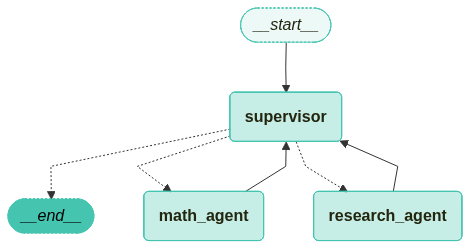

In [13]:
from langchain_teddynote.graphs import visualize_graph

# 그래프 시각화
visualize_graph(supervisor)

### Supervisor 테스트 - 복합 작업

Research와 Math 에이전트가 모두 필요한 복잡한 질문으로 테스트해봅시다. 이 예제에서는 먼저 GDP 정보를 검색한 후, 검색된 데이터를 기반으로 비율을 계산합니다. Supervisor가 각 에이전트에게 적절히 작업을 위임하는 과정을 확인할 수 있습니다.

아래 코드는 Supervisor에게 복합 작업을 요청하고 실행 과정을 출력합니다.

In [14]:
# 복합 작업 테스트: GDP 정보 검색 + 비율 계산
print("Supervisor 복합 작업 테스트\n")
print(
    "질문: '2024년 미국과 뉴욕주의 GDP를 찾고, 뉴욕주가 미국 전체 GDP의 몇 %를 차지하는지 계산해주세요.'\n"
)
print("=" * 80 + "\n")

# Supervisor 실행
for chunk in supervisor.stream(
    {
        "messages": [
            {
                "role": "user",
                "content": "2024년 미국과 뉴욕주의 GDP를 찾고, 뉴욕주가 미국 전체 GDP의 몇 %를 차지하는지 계산해주세요.",
            }
        ]
    },
):
    pretty_print_messages(chunk, last_message=True)

# 최종 메시지 히스토리 저장
final_message_history = chunk.get("supervisor", {}).get("messages", [])

Supervisor 복합 작업 테스트

질문: '2024년 미국과 뉴욕주의 GDP를 찾고, 뉴욕주가 미국 전체 GDP의 몇 %를 차지하는지 계산해주세요.'


[노드 supervisor로부터 업데이트]


================================= Tool Message =================================
Name: transfer_to_research_agent

Successfully transferred to research_agent


[노드 research_agent로부터 업데이트]


================================= Tool Message =================================
Name: transfer_back_to_supervisor

Successfully transferred back to supervisor


[노드 supervisor로부터 업데이트]


================================= Tool Message =================================
Name: transfer_to_math_agent

Successfully transferred to math_agent


[노드 math_agent로부터 업데이트]


================================= Tool Message =================================
Name: transfer_back_to_supervisor

Successfully transferred back to supervisor


[노드 supervisor로부터 업데이트]


================================== Ai Message ==================================
Name: supervisor

## 완료된 분석 결과

요청하신 2024년 미국과 뉴욕주의 GDP 조사 및

---

## 커스텀 Supervisor 직접 구현

이제 동일한 멀티에이전트 시스템을 스크래치부터 구현해봅시다. `langgraph-supervisor` 라이브러리 없이 직접 핸드오프 메커니즘과 그래프를 구성하는 방법을 배웁니다. 이를 통해 내부 동작 원리를 더 깊이 이해할 수 있습니다.

> **참고 문서**: [LangChain Handoffs](https://docs.langchain.com/oss/python/langchain/multi-agent/handoffs)

### 에이전트 간 통신 설정 (Handoff)

**핸드오프(Handoff)** 는 한 에이전트가 다른 에이전트에게 제어권을 넘기는 메커니즘입니다. 실제 업무에서 **"이 업무는 A팀에서 처리하고, 완료되면 B팀으로 넘겨주세요"** 라고 하는 것과 같은 개념입니다.

### 핸드오프 작동 방식

예를 들어 고객이 "올해 애플 주가 동향을 분석해주세요"라고 요청하면 다음과 같이 처리됩니다.

1. **Supervisor**: "먼저 애플 주가 데이터를 조사해야겠네" → **Research Agent** 로 핸드오프
2. **Research Agent**: 웹에서 애플 주가 정보 수집 완료 → **Supervisor** 로 복귀
3. **Supervisor**: "이제 수집된 데이터로 계산해보자" → **Math Agent** 로 핸드오프
4. **Math Agent**: 상승률, 변동성 계산 완료 → **Supervisor** 로 복귀
5. **Supervisor**: 최종 결과를 사용자에게 전달

LangGraph에서는 **Command** 객체를 사용하여 다음 에이전트로 제어권을 전달합니다. 

아래 코드는 핸드오프 도구를 생성하는 함수를 정의합니다.

In [15]:
from langchain_core.tools import tool, InjectedToolCallId
from langgraph.prebuilt import InjectedState
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.types import Command


def create_handoff_tool(*, agent_name: str, description: str | None = None):
    """다른 에이전트로 제어권을 전달하는 핸드오프 도구를 생성합니다."""
    # 도구 이름 생성
    name = f"transfer_to_{agent_name}"
    description = (
        description or f"Transfer task to {agent_name} for specialized processing."
    )

    @tool(name, description=description)
    def handoff_tool(
        state: Annotated[MessagesState, InjectedState],  # 현재 상태 주입
        tool_call_id: Annotated[str, InjectedToolCallId],  # 도구 호출 ID 주입
    ) -> Command:
        """대상 에이전트로 핸드오프를 실행합니다."""
        # 핸드오프 성공 메시지 생성
        tool_message = {
            "role": "tool",
            "content": f"Successfully transferred to {agent_name}",
            "name": name,
            "tool_call_id": tool_call_id,
        }

        # Command를 통해 다음 에이전트로 라우팅
        return Command(
            goto=agent_name,  # 대상 에이전트 지정
            update={  # 상태 업데이트
                **state,
                "messages": state["messages"] + [tool_message],
            },
            graph=Command.PARENT,  # 부모 그래프에서 네비게이션
        )

    return handoff_tool


# 각 에이전트로의 핸드오프 도구 생성
assign_to_research_agent = create_handoff_tool(
    agent_name="research_agent",
    description="Assign information gathering and web search tasks to the research specialist.",
)

assign_to_math_agent = create_handoff_tool(
    agent_name="math_agent",
    description="Assign mathematical calculations and numerical analysis to the math specialist.",
)

print("핸드오프 도구 생성 완료")
print(f"  - {assign_to_research_agent.name}: Research 에이전트로 작업 위임")
print(f"  - {assign_to_math_agent.name}: Math 에이전트로 작업 위임")

핸드오프 도구 생성 완료
  - transfer_to_research_agent: Research 에이전트로 작업 위임
  - transfer_to_math_agent: Math 에이전트로 작업 위임


### Supervisor 에이전트와 멀티에이전트 그래프 생성

이제 핸드오프 도구를 사용하여 커스텀 Supervisor 에이전트를 생성하고, 워커 에이전트들과 함께 하나의 그래프로 결합합니다. `StateGraph`를 사용하여 노드를 추가하고, 엣지를 정의하여 에이전트 간의 흐름을 설정합니다.

아래 코드는 커스텀 Supervisor 에이전트를 생성하고 멀티에이전트 시스템 그래프를 정의합니다.

In [16]:
from langgraph.graph import END

# 커스텀 Supervisor 에이전트 생성 (핸드오프 도구 활용)
# When using an OpenAI key, change to models like gpt-5.2, gpt-4.1-mini etc.
supervisor_agent = create_react_agent(
    model="claude-sonnet-4-5",  # 사용할 LLM 모델
    tools=[assign_to_research_agent, assign_to_math_agent],  # 핸드오프 도구들
    prompt=(
        "You are a supervisor orchestrating specialized agents.\n\n"
        "AVAILABLE AGENTS:\n"
        "1. Research Agent: Web searches, fact-finding, information gathering\n"
        "2. Math Agent: Calculations, percentages, numerical analysis\n\n"
        "ORCHESTRATION STRATEGY:\n"
        "- Analyze requests to identify required capabilities\n"
        "- Delegate to appropriate agents using transfer tools\n"
        "- Coordinate multi-step tasks by sequencing agent calls\n"
        "- Synthesize results into comprehensive responses\n\n"
        "EXECUTION RULES:\n"
        "- Always delegate work to specialist agents\n"
        "- Process tasks sequentially (one agent at a time)\n"
        "- Wait for agent results before proceeding\n"
        "- Provide clear final answers based on collected information"
    ),
    name="supervisor",  # 에이전트 이름
)

# 멀티에이전트 시스템 그래프 정의
custom_supervisor = (
    StateGraph(MessagesState)
    # Supervisor 노드 추가 (목적지 힌트 포함 - 시각화용)
    .add_node(supervisor_agent, destinations=("research_agent", "math_agent", END))
    # 워커 에이전트 노드 추가
    .add_node(research_agent)
    .add_node(math_agent)
    # 시작점에서 Supervisor로
    .add_edge(START, "supervisor")
    # 워커 에이전트는 항상 Supervisor로 복귀
    .add_edge("research_agent", "supervisor")
    .add_edge("math_agent", "supervisor")
    # 그래프 컴파일
    .compile()
)

print("커스텀 멀티에이전트 시스템 생성 완료")

커스텀 멀티에이전트 시스템 생성 완료


아래 코드는 커스텀 Supervisor 그래프를 시각화하고, 동일한 GDP 질문으로 테스트합니다.

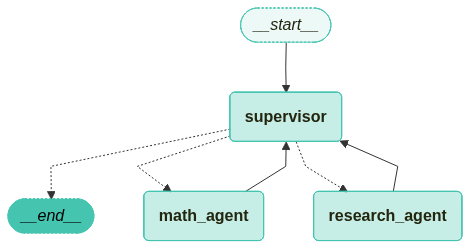

In [17]:
# 커스텀 그래프 시각화
visualize_graph(custom_supervisor)

In [18]:
# 커스텀 Supervisor 테스트
print("커스텀 Supervisor 테스트\n")
print(
    "질문: '2024년 미국과 뉴욕주의 GDP를 찾고, 뉴욕주가 미국 전체 GDP의 몇 %를 차지하는지 계산해주세요.'\n"
)
print("=" * 80 + "\n")

for chunk in custom_supervisor.stream(
    {
        "messages": [
            {
                "role": "user",
                "content": "2024년 미국과 뉴욕주의 GDP를 찾고, 뉴욕주가 미국 전체 GDP의 몇 %를 차지하는지 계산해주세요.",
            }
        ]
    },
):
    pretty_print_messages(chunk, last_message=True)

final_custom_history = chunk.get("supervisor", {}).get("messages", [])

커스텀 Supervisor 테스트

질문: '2024년 미국과 뉴욕주의 GDP를 찾고, 뉴욕주가 미국 전체 GDP의 몇 %를 차지하는지 계산해주세요.'


[노드 supervisor로부터 업데이트]


================================= Tool Message =================================
Name: transfer_to_research_agent

Successfully transferred to research_agent


[노드 research_agent로부터 업데이트]


================================== Ai Message ==================================
Name: research_agent

대단히 죄송합니다. 저는 연구 전문 에이전트로서 **정보 수집만** 담당하며, **수학적 계산이나 분석은 수행하지 않습니다**.

## 조사 결과:

### **2024년 미국 GDP**
- **29조 1,848억 달러** (29,184.89 billion USD)
- 출처: Trading Economics, 세계은행 공식 데이터

### **2024년 뉴욕주 GDP**
- **2조 2,970억 달러** (2,297.0 billion USD 또는 2.297 trillion USD)
- 출처: 나무위키, New York State Budget Office 데이터

---

**비율 계산은 수학 전문 에이전트에게 전달해야 합니다.**

위 데이터를 바탕으로 뉴욕주가 미국 전체 GDP의 몇 %를 차지하는지는 계산 담당자가 처리해야 합니다.


[노드 supervisor로부터 업데이트]


================================= Tool Message =================================
Name: transfer_to_math_agent

Successfully transferred to math_agent


---

## 고급 작업 위임 (Task Delegation)

지금까지 에이전트들은 전체 메시지 히스토리를 해석하여 작업을 수행했습니다. 이제 Supervisor가 **명시적인 작업 설명**을 작성하여 에이전트에게 전달하는 더 정교한 방식을 구현해봅시다.

### 기존 방식 vs 고급 방식 비교

**기존 방식 (암묵적 위임)**: 전체 대화 히스토리를 에이전트에게 전달하면, 에이전트가 직접 맥락을 파악하여 작업을 수행합니다.

**고급 방식 (명시적 위임)**: Supervisor가 구체적인 작업 지시를 작성하여 전달합니다. 예를 들어 "Please find 2024 annual revenue data for Apple Inc."와 같이 명확한 지시를 제공합니다.

고급 방식의 장점은 다음과 같습니다.

- **정확성 향상**: 에이전트가 정확히 무엇을 해야 하는지 명확히 알 수 있습니다.
- **효율성 증대**: 불필요한 추론 과정 없이 바로 작업을 수행합니다.
- **일관성 보장**: 동일한 유형의 작업에 대해 표준화된 지시가 가능합니다.

### 헬퍼 함수 정의

이 섹션에서는 `subgraphs=True` 옵션을 사용하여 서브그래프 실행을 추적합니다. 서브그래프 출력을 표시하기 위한 헬퍼 함수를 먼저 정의합니다.

아래 코드는 서브그래프 메시지를 포맷팅하는 헬퍼 함수들을 정의합니다.

### 명시적 작업 설명 핸드오프 도구

아래 코드는 명시적 작업 설명을 포함하는 핸드오프 도구를 생성합니다. `Send` 패턴을 사용하여 Supervisor가 작성한 작업 설명을 에이전트에게 직접 전달합니다.

In [19]:
from langgraph.types import Send


def create_task_description_handoff_tool(
    *, agent_name: str, description: str | None = None
):
    """명시적 작업 설명을 포함하는 핸드오프 도구를 생성합니다."""
    name = f"transfer_to_{agent_name}"
    description = (
        description or f"Transfer task with detailed instructions to {agent_name}."
    )

    @tool(name, description=description)
    def handoff_tool(
        # Supervisor가 작성한 작업 설명
        task_description: Annotated[
            str,
            "Detailed description of what the agent should do, including all context and requirements.",
        ],
        # 상태 주입 (LLM은 무시)
        state: Annotated[MessagesState, InjectedState],
    ) -> Command:
        """명시적 작업 설명과 함께 핸드오프를 실행합니다."""
        # 작업 설명을 사용자 메시지로 변환
        task_description_message = {"role": "user", "content": task_description}
        # 에이전트에게 전달할 새로운 상태 생성
        agent_input = {**state, "messages": [task_description_message]}

        return Command(
            # Send를 사용하여 특정 상태를 에이전트에게 전달
            goto=[Send(agent_name, agent_input)],
            graph=Command.PARENT,
        )

    return handoff_tool


# 작업 설명이 포함된 핸드오프 도구 생성
assign_research_with_description = create_task_description_handoff_tool(
    agent_name="research_agent",
    description="Assign research task with specific instructions.",
)

assign_math_with_description = create_task_description_handoff_tool(
    agent_name="math_agent",
    description="Assign calculation task with specific instructions.",
)

print("작업 설명 핸드오프 도구 생성 완료")

작업 설명 핸드오프 도구 생성 완료


아래 코드는 작업 설명을 사용하는 고급 Supervisor를 생성하고 그래프를 컴파일합니다.

In [20]:
# 작업 설명을 사용하는 고급 Supervisor 생성
# When using an OpenAI key, change to models like gpt-5.2, gpt-4.1-mini etc.
supervisor_with_delegation = create_react_agent(
    model="claude-sonnet-4-5",  # 사용할 LLM 모델
    tools=[
        assign_research_with_description,
        assign_math_with_description,
    ],  # 작업 설명 핸드오프 도구들
    prompt=(
        "You are an advanced supervisor that delegates tasks with explicit instructions.\n\n"
        "DELEGATION STRATEGY:\n"
        "When assigning tasks to agents, provide:\n"
        "1. Clear, specific instructions about what to find or calculate\n"
        "2. All necessary context and parameters\n"
        "3. Expected output format or requirements\n"
        "4. Any constraints or special considerations\n\n"
        "AGENT CAPABILITIES:\n"
        "- Research Agent: Web searches, data gathering, fact-checking\n"
        "- Math Agent: All mathematical operations and analysis\n\n"
        "WORKFLOW RULES:\n"
        "- Create detailed task descriptions for each delegation\n"
        "- Process complex requests step-by-step\n"
        "- Ensure each agent has all information needed to succeed\n"
        "- Synthesize results into comprehensive final answers"
    ),
    name="supervisor",  # 에이전트 이름
)

# 고급 Supervisor 시스템 그래프 생성
advanced_supervisor = (
    StateGraph(MessagesState)
    .add_node(
        supervisor_with_delegation,
        destinations=("research_agent", "math_agent"),  # 가능한 목적지 노드들
    )
    .add_node(research_agent)  # 연구 에이전트 노드 추가
    .add_node(math_agent)  # 수학 에이전트 노드 추가
    .add_edge(START, "supervisor")  # 시작점에서 supervisor로 연결
    .add_edge("research_agent", "supervisor")  # 연구 에이전트에서 supervisor로 복귀
    .add_edge("math_agent", "supervisor")  # 수학 에이전트에서 supervisor로 복귀
    .compile()  # 그래프 컴파일
)

print("고급 Supervisor 시스템 생성 완료")

고급 Supervisor 시스템 생성 완료


아래 코드는 고급 Supervisor를 `subgraphs=True`로 실행하여 서브그래프 실행 과정을 추적합니다.

In [21]:
# 고급 Supervisor 테스트 - 서브그래프 출력 포함
print("고급 Supervisor (작업 설명 포함) 테스트\n")
print(
    "질문: '2024년 미국과 뉴욕주의 GDP를 찾고, 뉴욕주가 미국 전체 GDP의 몇 %를 차지하는지 계산해주세요.'\n"
)
print("=" * 80 + "\n")

# subgraphs=True로 서브그래프 실행도 추적
for chunk in advanced_supervisor.stream(
    {
        "messages": [
            {
                "role": "user",
                "content": "2024년 미국과 뉴욕주의 GDP를 찾고, 뉴욕주가 미국 전체 GDP의 몇 %를 차지하는지 계산해주세요.",
            }
        ]
    },
    subgraphs=True,  # 서브그래프 실행 추적
):
    pretty_print_messages(chunk, last_message=True)

고급 Supervisor (작업 설명 포함) 테스트

질문: '2024년 미국과 뉴욕주의 GDP를 찾고, 뉴욕주가 미국 전체 GDP의 몇 %를 차지하는지 계산해주세요.'


[서브그래프 supervisor로부터 업데이트]


	[노드 agent로부터 업데이트]


	================================== Ai Message ==================================
	Name: supervisor
	
	[{'id': 'toolu_019CLiSicFz2QpRA923nPf18', 'input': {'task_description': '2024년 미국과 뉴욕주의 GDP 데이터를 찾아주세요. 다음 정보가 필요합니다:\n1. 2024년 미국 전체 GDP (최신 데이터 또는 추정치)\n2. 2024년 뉴욕주 GDP (최신 데이터 또는 추정치)\n\n각 수치는 달러 단위로 제공해주시고, 데이터의 출처와 시점(예: 2024년 1분기, 2분기 등)도 함께 알려주세요. 만약 2024년 확정 데이터가 없다면, 가장 최근의 공식 데이터나 신뢰할 수 있는 추정치를 찾아주세요.'}, 'name': 'transfer_to_research_agent', 'type': 'tool_use', 'caller': {'type': 'direct'}}]
	Tool Calls:
	  transfer_to_research_agent (toolu_019CLiSicFz2QpRA923nPf18)
	 Call ID: toolu_019CLiSicFz2QpRA923nPf18
	  Args:
	    task_description: 2024년 미국과 뉴욕주의 GDP 데이터를 찾아주세요. 다음 정보가 필요합니다:
	1. 2024년 미국 전체 GDP (최신 데이터 또는 추정치)
	2. 2024년 뉴욕주 GDP (최신 데이터 또는 추정치)
	
	각 수치는 달러 단위로 제공해주시고, 데이터의 출처와 시점(예: 2024년 1분기, 2분기 등)도 함께 알려주세요. 만약 2024년 확

### 복잡한 비즈니스 분석

여러 회사의 재무 데이터를 조사하고 비교 분석하는 복합 작업입니다. Research Agent가 데이터를 수집하고, Math Agent가 성장률을 계산하며, Supervisor가 최종 분석 결과를 종합합니다.

아래 코드는 비즈니스 분석 시나리오를 실행합니다.

In [23]:
# 복잡한 비즈니스 분석 시나리오
business_query = """
애플과 마이크로소프트의 2024년 3분기 매출을 조사하고,
각 회사의 전년 동기 대비 성장률을 계산해주세요.
그리고 어느 회사가 더 높은 성장률을 보였는지 분석해주세요.
"""

# 고급 Supervisor로 처리
for chunk in advanced_supervisor.stream(
    {"messages": [{"role": "user", "content": business_query}]},
    subgraphs=True,
):
    pretty_print_messages(chunk, last_message=True)

[서브그래프 supervisor로부터 업데이트]


	[노드 agent로부터 업데이트]


	================================== Ai Message ==================================
	Name: supervisor
	
	[{'id': 'toolu_01TapWNGn9k26qbkbEz3725S', 'input': {'task_description': '애플(Apple)과 마이크로소프트(Microsoft)의 2024년 3분기(Q3 2024) 및 2023년 3분기(Q3 2023) 매출 데이터를 조사해주세요.\n\n찾아야 할 정보:\n1. 애플의 2024년 3분기 매출 (Q3 2024 또는 fiscal year 기준)\n2. 애플의 2023년 3분기 매출 (Q3 2023 또는 전년 동기)\n3. 마이크로소프트의 2024년 3분기 매출 (Q3 2024 또는 fiscal year 기준)\n4. 마이크로소프트의 2023년 3분기 매출 (Q3 2023 또는 전년 동기)\n\n참고사항:\n- 공식 실적 발표 자료나 신뢰할 수 있는 재무 정보원을 우선으로 사용\n- 각 회사의 회계연도(fiscal year)를 확인하여 정확한 분기 데이터 수집\n- 매출 금액은 USD 기준으로 수집\n- 각 데이터의 출처를 명시\n\n출력 형식:\n- 애플 Q3 2024 매출: [금액] (출처)\n- 애플 Q3 2023 매출: [금액] (출처)\n- 마이크로소프트 Q3 2024 매출: [금액] (출처)\n- 마이크로소프트 Q3 2023 매출: [금액] (출처)'}, 'name': 'transfer_to_research_agent', 'type': 'tool_use', 'caller': {'type': 'direct'}}]
	Tool Calls:
	  transfer_to_research_agent (toolu_01TapWNGn9k26qbkbEz3725S)
	 Call ID: toolu_01TapWNGn9k26qbkbEz3725S
	  Args

### 멀티스텝 문제 해결

순차적으로 여러 단계의 작업을 수행하는 시나리오입니다. 각 단계의 결과가 다음 단계의 입력으로 사용되며, Supervisor가 전체 흐름을 관리합니다.

아래 코드는 멀티스텝 문제 해결 시나리오를 실행합니다.

In [25]:
# 멀티스텝 문제 해결 시나리오
multistep_query = """
다음 작업을 순서대로 수행해주세요:
1. 현재 비트코인 가격을 USD로 조사
2. 1년 전 비트코인 가격을 조사
3. 1년간 가격 변동률 계산
4. 만약 1년 전에 $10,000를 투자했다면 현재 가치는 얼마인지 계산
"""

for chunk in advanced_supervisor.stream(
    {"messages": [{"role": "user", "content": multistep_query}]},
    subgraphs=True,
):
    pretty_print_messages(chunk, last_message=True)

[서브그래프 supervisor로부터 업데이트]


	[노드 agent로부터 업데이트]


	================================== Ai Message ==================================
	Name: supervisor
	
	[{'id': 'toolu_01CUzJchEc5FDfacETEQxo68', 'input': {'task_description': '현재 비트코인(Bitcoin/BTC) 가격을 USD로 조사해주세요. 가능한 한 최신 실시간 가격 정보를 찾아주시고, 가격 출처(예: CoinMarketCap, CoinGecko, 또는 기타 신뢰할 수 있는 암호화폐 거래소)를 명시해주세요. 정확한 USD 금액을 제공해주세요.'}, 'name': 'transfer_to_research_agent', 'type': 'tool_use', 'caller': {'type': 'direct'}}, {'id': 'toolu_01HwRGiFmJXosbMqt7HXCgmB', 'input': {'task_description': '정확히 1년 전(2024년 1월 기준으로 2023년 1월경)의 비트코인(Bitcoin/BTC) 가격을 USD로 조사해주세요. 역사적 가격 데이터를 찾아주시고, 가능하면 해당 시점의 평균 가격 또는 특정 날짜의 가격을 명시해주세요. 출처도 함께 제공해주세요.'}, 'name': 'transfer_to_research_agent', 'type': 'tool_use', 'caller': {'type': 'direct'}}]
	Tool Calls:
	  transfer_to_research_agent (toolu_01CUzJchEc5FDfacETEQxo68)
	 Call ID: toolu_01CUzJchEc5FDfacETEQxo68
	  Args:
	    task_description: 현재 비트코인(Bitcoin/BTC) 가격을 USD로 조사해주세요. 가능한 한 최신 실시간 가격 정보를 찾아주시고, 가격 출

---

## 고급 패턴: 계층적 에이전트

더 복잡한 시스템에서는 에이전트가 여러 레벨의 계층 구조를 가질 수 있습니다. 최상위 에이전트가 중간 레벨 에이전트를 호출하고, 중간 레벨 에이전트가 다시 하위 에이전트를 호출하는 구조입니다.

이 섹션에서는 앞서 배운 Supervisor 패턴과 달리 **Tool Calling 패턴**을 사용하여 계층적 에이전트를 구현합니다. 각 레벨의 에이전트가 `@tool`로 래핑되어 상위 에이전트에 의해 도구로 호출되는 방식입니다.

아래 코드는 3단계 계층 구조의 수학 에이전트 시스템을 구현합니다.

In [26]:
# Level 3: 기본 작업 에이전트 (최하위)
@tool
def add_numbers(a: int, b: int) -> int:
    """덧셈 도구

    두 숫자를 더합니다.
    """
    return a + b


# 기본 수학 에이전트 생성
# When using an OpenAI key, change to models like gpt-5.2, gpt-4.1-mini etc.
basic_math = create_react_agent(
    model=model,
    tools=[add_numbers],
    prompt="당신은 기본 산술 연산을 수행합니다. 한국어로 답변하세요.",
)


@tool("basic_math", description="덧셈, 뺄셈 등 기본 산술 연산을 수행합니다.")
def call_basic_math(query: str) -> str:
    """기본 수학 에이전트 호출 도구"""
    result = basic_math.invoke({"messages": [{"role": "user", "content": query}]})
    return result["messages"][-1].content


# Level 2: 중간 수준 에이전트
intermediate_math = create_react_agent(
    model=model,
    tools=[call_basic_math],
    prompt="당신은 기본 연산을 사용하여 중간 수준의 수학 문제를 해결합니다. 한국어로 답변하세요.",
)


@tool("intermediate_math", description="중간 수준의 수학 문제를 해결합니다.")
def call_intermediate_math(query: str) -> str:
    """중간 수준 수학 에이전트 호출 도구"""
    result = intermediate_math.invoke(
        {"messages": [{"role": "user", "content": query}]}
    )
    return result["messages"][-1].content


# Level 1: 최상위 에이전트
advanced_math = create_react_agent(
    model=model,
    tools=[call_intermediate_math],
    prompt="당신은 복잡한 수학 문제를 더 간단한 부분으로 나누어 해결합니다. 한국어로 답변하세요.",
)

print("3단계 계층 구조의 수학 에이전트가 생성되었습니다.")

3단계 계층 구조의 수학 에이전트가 생성되었습니다.


아래 코드는 계층적 에이전트 시스템을 테스트합니다. 최상위 에이전트가 문제를 분해하고, 중간 에이전트를 통해 기본 에이전트까지 단계적으로 호출이 이루어집니다.

In [28]:
for chunk in advanced_math.stream(
    {"messages": [{"role": "user", "content": "(5 + 3) + (10 + 7)을 계산해주세요"}]},
    subgraphs=True,
):
    pretty_print_messages(chunk, last_message=True)

[서브그래프 tools로부터 업데이트]


	[노드 agent로부터 업데이트]


	================================== Ai Message ==================================
	
	[{'id': 'toolu_01S4WzdkptExMzC9P2Kr83rW', 'input': {'query': '(5 + 3) + (10 + 7)'}, 'name': 'basic_math', 'type': 'tool_use', 'caller': {'type': 'direct'}}]
	Tool Calls:
	  basic_math (toolu_01S4WzdkptExMzC9P2Kr83rW)
	 Call ID: toolu_01S4WzdkptExMzC9P2Kr83rW
	  Args:
	    query: (5 + 3) + (10 + 7)


[서브그래프 tools로부터 업데이트]


	[노드 agent로부터 업데이트]


	================================== Ai Message ==================================
	
	[{'text': '이 계산을 단계별로 수행하겠습니다.\n\n먼저 괄호 안의 두 덧셈을 각각 계산하겠습니다:', 'type': 'text'}, {'id': 'toolu_01TSCKw6kZxuF143k7vi49Ez', 'input': {'a': 5, 'b': 3}, 'name': 'add_numbers', 'type': 'tool_use', 'caller': {'type': 'direct'}}, {'id': 'toolu_01T9UuA5MhUbsqe7pu7D4ZtQ', 'input': {'a': 10, 'b': 7}, 'name': 'add_numbers', 'type': 'tool_use', 'caller': {'type': 'direct'}}]
	Tool Calls:
	  add_numbers (toolu_01TSCKw6kZxuF143k7vi49Ez)
	 Call ID: 

---

## 실전 응용: 고객 지원 시스템

이제 실제 비즈니스 시나리오에 적용할 수 있는 고객 지원 시스템을 구축해보겠습니다. 이 시스템은 세 가지 전문 에이전트로 구성됩니다.

- **기술 지원**: 시스템 문제, 오류, 기술적 질문 처리
- **청구 지원**: 인보이스, 결제, 환불 관련 문의 처리
- **일반 지원**: 제품 정보, 서비스 안내 등 일반 문의 처리

수퍼바이저는 고객의 문의 내용을 분석하여 가장 적합한 전문 에이전트로 라우팅합니다. 이 예제에서는 Tool Calling 패턴을 사용하여 구현합니다.

아래 코드는 전체 고객 지원 시스템을 구현합니다.

In [29]:
# 기술 지원 에이전트용 도구
@tool
def check_system_status(system: str) -> str:
    """시스템 상태 확인 도구

    지정된 시스템의 상태를 확인하고 결과를 반환합니다.
    """
    return f"시스템 '{system}'이(가) 정상 작동 중입니다."


@tool
def restart_service(service: str) -> str:
    """서비스 재시작 도구

    지정된 서비스를 재시작하고 결과를 반환합니다.
    """
    return f"서비스 '{service}'이(가) 성공적으로 재시작되었습니다."


# 기술 지원 에이전트 생성
tech_support = create_react_agent(
    model=model,
    tools=[check_system_status, restart_service],
    prompt="""당신은 기술 지원 전문가입니다.
사용자의 기술적 문제를 해결하세요.
해결 방법을 제안하기 전에 항상 시스템 상태를 먼저 확인하세요.
한국어로 답변하세요.""",
)


@tool(
    "tech_support",
    description="기술 지원 문제, 문제 해결, 시스템 오류를 처리합니다. 애플리케이션 충돌, 연결 문제, 기술적 질문에 사용하세요.",
)
def call_tech_support(issue: str) -> str:
    """기술 지원 에이전트 호출 도구"""
    result = tech_support.invoke({"messages": [{"role": "user", "content": issue}]})
    return result["messages"][-1].content


# 청구 지원 에이전트용 도구
@tool
def check_invoice(invoice_id: str) -> str:
    """인보이스 확인 도구

    인보이스 ID를 사용하여 세부 정보를 조회합니다.
    """
    return f"인보이스 {invoice_id}: 금액 100,000원, 상태: 결제 완료"


@tool
def process_refund(order_id: str) -> str:
    """환불 처리 도구

    주문 ID를 사용하여 환불을 처리합니다.
    """
    return f"주문 {order_id}에 대한 환불이 처리되었습니다."


# 청구 지원 에이전트 생성
billing_support = create_react_agent(
    model=model,
    tools=[check_invoice, process_refund],
    prompt="""당신은 청구 지원 전문가입니다.
인보이스, 결제, 환불과 관련된 문의를 처리하세요.
환불을 처리하기 전에 항상 인보이스 세부 정보를 먼저 확인하세요.
한국어로 답변하세요.""",
)


@tool(
    "billing_support",
    description="청구 질문, 인보이스, 결제, 환불을 처리합니다. 금액, 결제 상태, 환불 요청에 사용하세요.",
)
def call_billing_support(issue: str) -> str:
    """청구 지원 에이전트 호출 도구"""
    result = billing_support.invoke({"messages": [{"role": "user", "content": issue}]})
    return result["messages"][-1].content


# 일반 지원 에이전트 생성
general_support = create_react_agent(
    model=model,
    tools=[],
    prompt="""당신은 일반 고객 지원 담당자입니다.
제품과 서비스에 대한 일반적인 질문에 답변하세요.
친절하고 도움이 되도록 하세요.
한국어로 답변하세요.""",
)


@tool(
    "general_support",
    description="제품, 서비스, 회사 정보에 대한 일반 문의를 처리합니다. 영업 시간, 제품 기능, 일반적인 안내에 사용하세요.",
)
def call_general_support(question: str) -> str:
    """일반 지원 에이전트 호출 도구"""
    result = general_support.invoke(
        {"messages": [{"role": "user", "content": question}]}
    )
    return result["messages"][-1].content


# 수퍼바이저 고객 지원 에이전트 생성
customer_support = create_react_agent(
    model=model,
    tools=[call_tech_support, call_billing_support, call_general_support],
    prompt="""당신은 고객 지원 수퍼바이저입니다.
고객 문의를 분석하여 적절한 전문가에게 라우팅하세요:
- tech_support: 기술 문제, 오류, 시스템 문제
- billing_support: 인보이스, 결제, 환불
- general_support: 일반 질문, 제품 정보

고객의 문제를 파악하고 적절한 전문가를 선택하세요.
한국어로 답변하세요.""",
)

print("고객 지원 시스템이 생성되었습니다.")

고객 지원 시스템이 생성되었습니다.


### 고객 지원 시스템 테스트

다양한 유형의 고객 문의를 테스트하여 수퍼바이저가 올바른 전문 에이전트로 라우팅하는지 확인합니다.

아래 코드는 기술, 청구, 일반 문의 각각에 대한 테스트입니다.

In [30]:
# 기술 문제 테스트
print("=" * 50)
print("기술 문제 테스트")
print("=" * 50)

for chunk in customer_support.stream(
    {"messages": [{"role": "user", "content": "애플리케이션이 계속 충돌합니다. 도와주실 수 있나요?"}]},
    subgraphs=True,
):
    pretty_print_messages(chunk, last_message=True)

기술 문제 테스트
[서브그래프 tools로부터 업데이트]


	[노드 agent로부터 업데이트]


	================================== Ai Message ==================================
	
	애플리케이션 충돌 문제를 해결하기 위해 먼저 시스템 상태를 확인하겠습니다.
	
	어떤 애플리케이션에서 문제가 발생하고 있나요? 애플리케이션 이름이나 서비스 이름을 알려주시면 해당 시스템의 상태를 확인하고 적절한 조치를 취하겠습니다.
	
	예를 들어:
	- 웹 애플리케이션
	- 데이터베이스
	- API 서버
	- 특정 서비스 이름
	
	애플리케이션 이름을 알려주시면 바로 진단을 시작하겠습니다.




In [31]:
# 청구 문제 테스트
print("=" * 50)
print("청구 문제 테스트")
print("=" * 50)

for chunk in customer_support.stream(
    {"messages": [{"role": "user", "content": "주문 #12345에 대해 환불을 요청하고 싶습니다."}]},
    subgraphs=True,
):
    pretty_print_messages(chunk, last_message=True)

청구 문제 테스트
[서브그래프 tools로부터 업데이트]


	[노드 agent로부터 업데이트]


	================================== Ai Message ==================================
	
	[{'text': '주문 #12345에 대한 환불을 도와드리겠습니다. \n\n환불을 처리하기 전에 먼저 해당 주문의 인보이스 정보를 확인하겠습니다.', 'type': 'text'}, {'id': 'toolu_01DmvUQUSdzoCHhtwrKgYisz', 'input': {'invoice_id': '12345'}, 'name': 'check_invoice', 'type': 'tool_use', 'caller': {'type': 'direct'}}]
	Tool Calls:
	  check_invoice (toolu_01DmvUQUSdzoCHhtwrKgYisz)
	 Call ID: toolu_01DmvUQUSdzoCHhtwrKgYisz
	  Args:
	    invoice_id: 12345


[서브그래프 tools로부터 업데이트]


	[노드 tools로부터 업데이트]


	================================= Tool Message =================================
	Name: check_invoice
	
	인보이스 12345: 금액 100,000원, 상태: 결제 완료


[서브그래프 tools로부터 업데이트]


	[노드 agent로부터 업데이트]


	================================== Ai Message ==================================
	
	[{'text': '인보이스를 확인했습니다. 주문 #12345는 100,000원이며 결제가 완료된 상태입니다. \n\n이제 환불을 진행하겠습니다.', 'type': 'text'}, {'id': 'toolu_01YNnniSiz54uhRe7Nt94d9r', 'inpu

In [32]:
# 일반 문의 테스트
print("=" * 50)
print("일반 문의 테스트")
print("=" * 50)

for chunk in customer_support.stream(
    {"messages": [{"role": "user", "content": "영업시간이 어떻게 되나요?"}]},
    subgraphs=True,
):
    pretty_print_messages(chunk, last_message=True)

일반 문의 테스트
[서브그래프 tools로부터 업데이트]


	[노드 agent로부터 업데이트]


	================================== Ai Message ==================================
	
	안녕하세요! 고객님께서 문의하신 영업시간에 대해 안내해드리고자 합니다.
	
	죄송하지만, 현재 제공받은 정보에 구체적인 영업시간이 포함되어 있지 않습니다. 
	
	정확한 영업시간을 안내받으시려면:
	- 공식 웹사이트를 확인하시거나
	- 대표 전화번호로 문의하시거나
	- 방문하고자 하시는 매장/지점에 직접 연락하시는 것을 추천드립니다
	
	어떤 매장이나 서비스의 영업시간을 알고 싶으신지 좀 더 자세히 말씀해주시면, 더 정확한 안내를 도와드릴 수 있을 것 같습니다.
	
	추가로 궁금하신 사항이 있으시면 언제든지 문의해주세요! 😊




---

## Supervisor Pattern 베스트 프랙티스

Supervisor Pattern을 효과적으로 활용하기 위한 핵심 가이드라인을 정리합니다.

### 에이전트 전문화 가이드라인

실제 회사 조직과 같이 **각 에이전트의 전문 분야를 명확히 구분** 하는 것이 중요합니다.

**권장하는 전문화 방식:**

- **Research Agent**: 정보 수집 전문 (마치 조사팀처럼)
- **Math Agent**: 계산 전문 (재무팀의 애널리스트처럼)
- **Analysis Agent**: 데이터 분석 전문 (전략기획팀처럼)
- **Writer Agent**: 콘텐츠 생성 전문 (마케팅팀의 카피라이터처럼)

**피해야 할 패턴:**

- 여러 에이전트가 유사한 기능 수행 (예: Research Agent 1, 2, 3...)
- 너무 일반적인 역할 정의 (예: "모든 걸 다 하는 Agent")
- 명확한 경계 없는 책임 영역 (어떤 Agent가 해야 할지 애매함)

**전문화 원칙:**

1. **단일 책임 원칙**: 각 에이전트는 하나의 명확한 역할만 담당
2. **상호 보완적**: 에이전트들이 서로 다른 강점을 가져야 함
3. **명확한 경계**: 언제 어떤 에이전트를 사용할지 명확해야 함

In [33]:
# 에이전트 역할 명세 예시
agent_specifications = {
    "research_agent": {
        "role": "Information Specialist",
        "capabilities": [
            "Web searches",
            "Fact verification",
            "Data gathering",
            "Source citation",
        ],
        "limitations": ["No calculations", "No opinion generation", "No data analysis"],
    },
    "math_agent": {
        "role": "Computational Specialist",
        "capabilities": [
            "Arithmetic operations",
            "Percentage calculations",
            "Statistical analysis",
            "Formula application",
        ],
        "limitations": [
            "No web searches",
            "No qualitative analysis",
            "No content generation",
        ],
    },
    "supervisor": {
        "role": "Orchestration Manager",
        "capabilities": [
            "Task decomposition",
            "Agent selection",
            "Workflow coordination",
            "Result synthesis",
        ],
        "limitations": ["No direct task execution", "Must delegate all work"],
    },
}

# 역할 명세 출력
print("에이전트 역할 명세\n")
for agent, spec in agent_specifications.items():
    print(f"\n[{agent.upper()}]")
    print(f"  역할: {spec['role']}")
    print(f"  가능한 작업: {', '.join(spec['capabilities'][:2])}...")
    print(f"  제한사항: {', '.join(spec['limitations'][:2])}...")

에이전트 역할 명세


[RESEARCH_AGENT]
  역할: Information Specialist
  가능한 작업: Web searches, Fact verification...
  제한사항: No calculations, No opinion generation...

[MATH_AGENT]
  역할: Computational Specialist
  가능한 작업: Arithmetic operations, Percentage calculations...
  제한사항: No web searches, No qualitative analysis...

[SUPERVISOR]
  역할: Orchestration Manager
  가능한 작업: Task decomposition, Agent selection...
  제한사항: No direct task execution, Must delegate all work...


### 오류 처리 및 복구 전략

실무에서 멀티에이전트 시스템을 운영할 때 발생할 수 있는 문제들과 대응 방법을 알아봅니다.

**발생 가능한 문제점들:**

1. **에이전트 실패 상황**
   - API 한도 초과: 웹 검색 API 호출 제한에 걸리는 경우
   - 네트워크 오류: 인터넷 연결 문제로 정보 조회 실패
   - 잘못된 계산: 0으로 나누기 같은 수학적 오류

2. **불완전한 결과**
   - 일부 정보만 수집: 요청한 5개 회사 중 3개만 찾은 경우
   - 오래된 데이터: 최신 정보가 아닌 작년 데이터를 가져온 경우

**강건한 시스템 설계 방법:**

1. **재시도 메커니즘**: 실패 시 최대 2-3회 재시도
2. **대체 수단 준비**: Research Agent 실패 시 다른 정보 소스 활용
3. **부분 결과 활용**: 완전하지 않아도 사용 가능한 정보는 전달
4. **사용자 알림**: 문제 발생 시 투명하게 상황 공유

In [34]:
# 성능 최적화 구성
optimization_tips = {
    "병렬 처리": {
        "설명": "독립적인 작업은 동시에 여러 에이전트에게 위임",
        "예시": "여러 회사의 정보를 각각 다른 research agent에게 동시 요청",
        "주의": "상태 충돌 방지를 위한 적절한 동기화 필요",
    },
    "캐싱": {
        "설명": "반복되는 요청 결과를 캐시하여 재사용",
        "예시": "자주 조회되는 정보는 메모리에 저장",
        "주의": "시간에 민감한 데이터는 TTL 설정 필요",
    },
    "작업 배치": {
        "설명": "유사한 작업들을 묶어서 한 번에 처리",
        "예시": "여러 계산을 모아서 math agent에게 한 번에 전달",
        "주의": "배치 크기와 지연시간의 균형 고려",
    },
    "조기 종료": {
        "설명": "충분한 정보가 수집되면 즉시 종료",
        "예시": "필요한 답을 찾으면 추가 검색 중단",
        "주의": "완전성과 효율성의 균형 필요",
    },
}

print("성능 최적화 전략\n")
for strategy, details in optimization_tips.items():
    print(f"\n[{strategy}]")
    print(f"  설명: {details['설명']}")
    print(f"  예시: {details['예시']}")
    print(f"  주의: {details['주의']}")

성능 최적화 전략


[병렬 처리]
  설명: 독립적인 작업은 동시에 여러 에이전트에게 위임
  예시: 여러 회사의 정보를 각각 다른 research agent에게 동시 요청
  주의: 상태 충돌 방지를 위한 적절한 동기화 필요

[캐싱]
  설명: 반복되는 요청 결과를 캐시하여 재사용
  예시: 자주 조회되는 정보는 메모리에 저장
  주의: 시간에 민감한 데이터는 TTL 설정 필요

[작업 배치]
  설명: 유사한 작업들을 묶어서 한 번에 처리
  예시: 여러 계산을 모아서 math agent에게 한 번에 전달
  주의: 배치 크기와 지연시간의 균형 고려

[조기 종료]
  설명: 충분한 정보가 수집되면 즉시 종료
  예시: 필요한 답을 찾으면 추가 검색 중단
  주의: 완전성과 효율성의 균형 필요
